# H2: Defensive Vigor Unfolds as a Threat-Graded Anticipatory Ramp and a Stereotyped Reactive Surge

**Section claim (paper §2):** Defensive vigor has two distinct temporal components — an anticipatory ramp that scales with threat, and a reactive surge triggered by predator encounter.

## Tests (both cross-sample)

| # | Test | Data | Method |
|---|---|---|---|
| **2.1** | Encounter triggers a per-subject reactive surge | `vigor_metrics.csv` reactive epoch | One-sample t-test on per-subject (attack − no-attack) — preregistered H2a |
| **2.2** | Anticipatory pressing rate scales with threat | `vigor_metrics.csv` anticipatory epoch | LMM `norm_rate ~ T_round + cookie + (1|subj)` |

Two tests, one for each component of the dual-component claim. Both have to pass in both samples for the §2 framework.

**Replacing the preregistered GAM:** The H2b GAM (cubic regression splines K=10) tested an omnibus "smooth differs by condition" claim. The two feature-specific tests above are more interpretable, faster, and answer the *mechanistic* question (what about the shape differs) rather than the omnibus question (does anything about the shape differ). The GAM is deferred to a supplementary sensitivity analysis.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, os
# Ensure notebooks/analysis is on sys.path so config + load_data resolve when run via nbconvert
_NB_DIR = '/Users/nokada/Documents/CALTECH/EffortForagingUnderThreat/notebooks/analysis'
if _NB_DIR not in sys.path: sys.path.insert(0, _NB_DIR)
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import ttest_rel, ttest_1samp, chi2, pearsonr, linregress
from config import *
from load_data import load_both

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.right': False, 'axes.spines.top': False})

exp_data, conf_data = load_both()
all_data = {k: v for k, v in [('exploratory', exp_data), ('confirmatory', conf_data)] if v is not None}
for name, d in all_data.items():
    print(f'{d["config"].label}: trials={len(d["beh"])}, subj={d["beh"]["subj"].nunique()}, vigor_metrics={len(d.get("vigor_metrics", []))}')

# Smoothed timecourse — exploratory only at this time
TS_PATHS = {
    'exploratory': REPO_ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed' / 'smoothed_vigor_ts.parquet',
    'confirmatory': REPO_ROOT / 'data' / 'confirmatory_350' / 'processed' / 'vigor_processed' / 'smoothed_vigor_ts.parquet',
}
ts_data = {}
for sample, p in TS_PATHS.items():
    if Path(p).exists():
        ts_data[sample] = pd.read_parquet(p)
        print(f'{sample} timecourse: {ts_data[sample].shape}')
    else:
        print(f'{sample} timecourse: NOT YET PROCESSED — exploratory-only for H2b–H2g time-resolved analyses')

Exploratory (N=290): stage5_filtered_data_20260403_133425 | params: 290 subjects
Confirmatory (N=281): stage5_filtered_data_20260403_142413 | params: 281 subjects
GPU: No


Exploratory (N=290): trials=23490, subj=290, vigor_metrics=105017
Confirmatory (N=281): trials=22761, subj=281, vigor_metrics=101487


exploratory timecourse: (3988277, 19)
confirmatory timecourse: NOT YET PROCESSED — exploratory-only for H2b–H2g time-resolved analyses


## §2.1 — Encounter triggers a per-subject reactive surge (preregistered H2a)

Per-subject mean reactive-epoch pressing rate on attack minus non-attack trials; one-sample t-test against zero. Both samples.

**Pass criterion:** p < .001 and d > 0.20 in both samples.

In [2]:
# H2a — uses per-sample vigor_metrics CSVs directly (load_both has a known bug returning
# the root vigor_metrics.csv for both samples, so we read per-sample files explicitly).
h2a_results = []
VM_PATHS = {
    'exploratory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'exploratory' / 'vigor_metrics.csv',
    'confirmatory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'confirmatory' / 'vigor_metrics.csv',
}
for sample, vm_path in VM_PATHS.items():
    if not Path(vm_path).exists():
        print(f'{sample}: vigor_metrics.csv not found at {vm_path}'); continue
    vm = pd.read_csv(vm_path)
    # Apply standard exclusions from the sample config
    cfg = all_data[sample]['config']
    vm = vm[~vm['subj'].isin(cfg.exclude)]
    label = cfg.label
    reactive = vm[vm['epoch'] == 'reactive']
    s_a = reactive[reactive['is_attack'] == 1].groupby('subj')['norm_rate'].mean()
    s_n = reactive[reactive['is_attack'] == 0].groupby('subj')['norm_rate'].mean()
    shared = sorted(set(s_a.index) & set(s_n.index))
    spike = s_a.loc[shared] - s_n.loc[shared]
    t_spike, p_spike = ttest_1samp(spike.dropna(), 0)
    d_spike = spike.mean() / spike.std()
    pct_pos = (spike > 0).mean() * 100
    passed = p_spike < 0.001 and d_spike > 0.20
    print(f'\nH2a {label} (N_subj={len(shared)}):')
    print(f'  mean spike={spike.mean():+.4f}, t={t_spike:.2f}, p={p_spike:.2e}, d={d_spike:+.3f}, {pct_pos:.0f}% positive')
    print(f'  {"PASS" if passed else "FAIL"}')
    h2a_results.append({'sample': sample, 't': t_spike, 'p': p_spike, 'd': d_spike, 'pct_pos': pct_pos, 'pass': passed})


H2a Exploratory (N=290) (N_subj=290):
  mean spike=+0.0358, t=11.01, p=8.73e-24, d=+0.647, 83% positive
  PASS

H2a Confirmatory (N=281) (N_subj=281):
  mean spike=+0.0253, t=7.90, p=6.58e-14, d=+0.471, 74% positive
  PASS


Time to peak (s): median = 1.117, IQR = [0.847, 1.412]

Loading raw press data from behavior_rich.csv...


  Loaded 23316 trials across 290 subjects


  Per-trial baseline-corrected difference curves built per T; ~290 subjects per cell


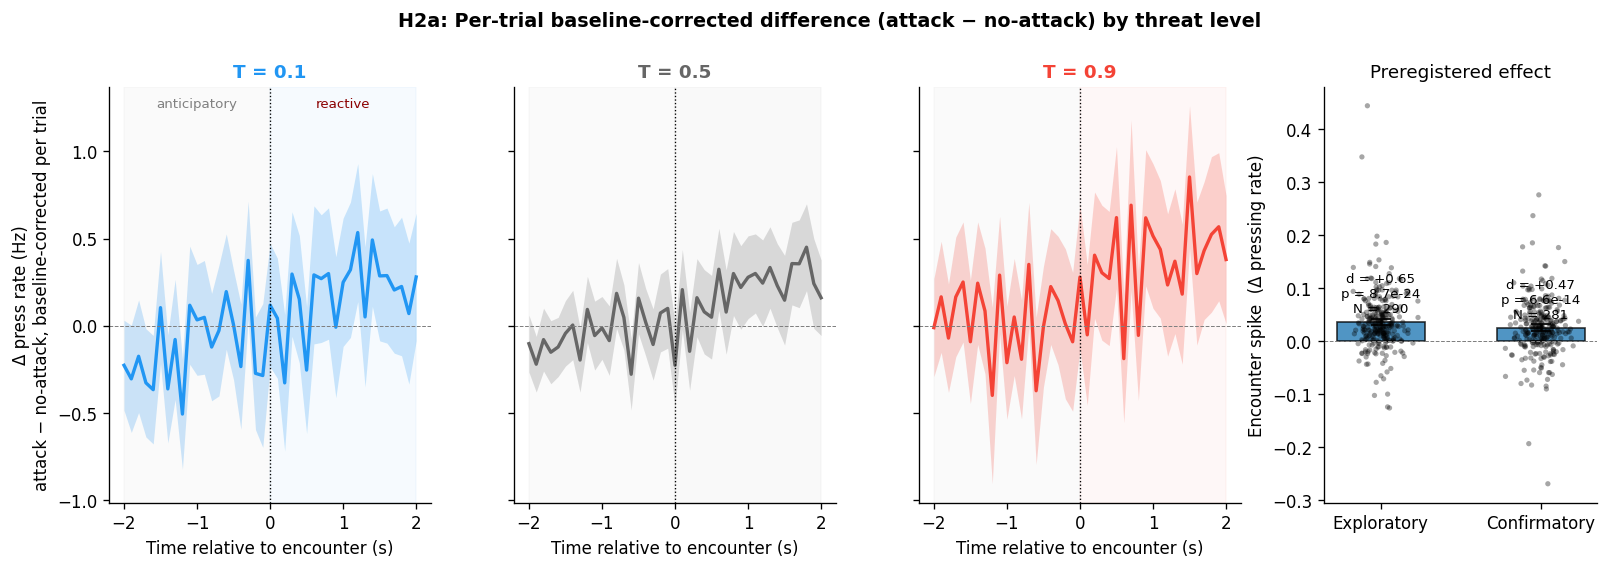


Saved H2a figure: /Users/nokada/Documents/CALTECH/EffortForagingUnderThreat/results/figs/paper/H2a_encounter_spike.png


In [3]:
# H2a extension — surge timing (for H2g use) + paper-ready H2a figure
# Figure design (neuroscience-style PSTH spike isolation):
#   Step 1 — per-trial baseline-correct: subtract trial's pre-event mean count → handles trial state
#   Step 2 — per (subj, T) take attack − no-attack difference of baseline-corrected rate → cancels trajectory
#   Step 3 — three T-stratified subplots; spike isolated as clean post-event positive excursion
#   + 1 preregistered bar plot panel for cross-sample replication.
if 'exploratory' in ts_data:
    ts = ts_data['exploratory']

    # ----- Surge timing (used by H2g) -----
    attk = ts[(ts['isAttackTrial'] == 1) & ts['encounterTime'].notna()].copy()
    attk['t_rel'] = attk['t'] - attk['encounterTime']
    pre_mask = (attk['t_rel'] >= -1.0) & (attk['t_rel'] < -0.1)
    post_mask = (attk['t_rel'] >= 0.0) & (attk['t_rel'] <= 1.5)
    pre = attk[pre_mask].groupby(['subj', 'trial'])['r_hat'].agg(['mean', 'std']).reset_index().rename(columns={'mean': 'pre_mean', 'std': 'pre_sd'})
    post = attk[post_mask].copy().merge(pre, on=['subj', 'trial'])
    post['thresh'] = post['pre_mean'] + 0.5 * post['pre_sd']
    post['exceed'] = post['r_hat'] > post['thresh']
    lat = post[post['exceed']].groupby(['subj', 'trial'])['t_rel'].min().reset_index().rename(columns={'t_rel': 'latency'})
    peak_idx = post.groupby(['subj', 'trial'])['r_hat'].idxmax()
    peak_info = post.loc[peak_idx][['subj', 'trial', 't_rel', 'r_hat']].rename(columns={'t_rel': 'ttp', 'r_hat': 'peak_amp'})
    timing = lat.merge(peak_info, on=['subj', 'trial'])
    timing_subj = timing.groupby('subj')[['latency', 'ttp', 'peak_amp']].median().reset_index()
    print(f'Time to peak (s): median = {timing_subj["ttp"].median():.3f}, IQR = [{timing_subj["ttp"].quantile(0.25):.3f}, {timing_subj["ttp"].quantile(0.75):.3f}]')

    # ============================================================
    # Per-trial baseline-corrected PSTH + difference per T
    # ============================================================
    import ast
    BR_PATH = REPO_ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_20260403_133425' / 'behavior_rich.csv'
    print(f'\nLoading raw press data from {BR_PATH.name}...')
    br = pd.read_csv(BR_PATH)
    cfg_exp = all_data['exploratory']['config']
    br = br[~br['subj'].isin(cfg_exp.exclude)].copy()
    br = br[br['alignedEffortRate'].notna() & br['encounterTime'].notna()].copy()
    br['press_times'] = br['alignedEffortRate'].apply(ast.literal_eval)
    br['n_presses_total'] = br['press_times'].apply(len)
    br = br[br['n_presses_total'] > 0].copy()
    br['T_round'] = br['threat'].round(1)
    print(f'  Loaded {len(br)} trials across {br["subj"].nunique()} subjects')

    expl = br[['subj', 'trial', 'encounterTime', 'isAttackTrial', 'T_round', 'press_times']].explode('press_times').copy()
    expl['press_time'] = expl['press_times'].astype(float)
    expl['press_rel'] = expl['press_time'] - expl['encounterTime']

    BIN_WIDTH = 0.10
    expl = expl[(expl['press_rel'] >= -2.0) & (expl['press_rel'] <= 2.0)].copy()
    expl['bin_idx'] = np.round(expl['press_rel'] / BIN_WIDTH).astype(int)
    expl['t_bin'] = (expl['bin_idx'] * BIN_WIDTH).round(2)

    bin_grid_int = np.arange(int(-2.0 / BIN_WIDTH), int(2.0 / BIN_WIDTH) + 1)
    bin_grid = pd.DataFrame({'t_bin': (bin_grid_int * BIN_WIDTH).round(2)})
    counts_trial = expl.groupby(['subj', 'trial', 't_bin']).size().reset_index(name='count')
    trial_info = br[['subj', 'trial', 'T_round', 'isAttackTrial']].copy()
    trial_full = trial_info.merge(bin_grid, how='cross').merge(counts_trial, on=['subj', 'trial', 't_bin'], how='left')
    trial_full['count'] = trial_full['count'].fillna(0).astype(int)

    # PER-TRIAL BASELINE: mean count in [-1, -0.1] s
    BASELINE_LO, BASELINE_HI = -1.0, -0.1
    base_mask = (trial_full['t_bin'] >= BASELINE_LO) & (trial_full['t_bin'] < BASELINE_HI)
    trial_baseline = trial_full[base_mask].groupby(['subj', 'trial'])['count'].mean().reset_index().rename(columns={'count': 'baseline_count'})
    trial_full = trial_full.merge(trial_baseline, on=['subj', 'trial'], how='inner')
    trial_full['rate_corrected_hz'] = (trial_full['count'] - trial_full['baseline_count']) / BIN_WIDTH

    # Aggregate per (subj, T, isAttack, t_bin) — mean of baseline-corrected rate across that subject's trials
    subj_psth = trial_full.groupby(['subj', 'T_round', 'isAttackTrial', 't_bin'])['rate_corrected_hz'].mean().reset_index()
    # Pivot to attack vs noattack columns per (subj, T, t_bin)
    pivot = subj_psth.pivot_table(index=['subj', 'T_round', 't_bin'], columns='isAttackTrial', values='rate_corrected_hz').reset_index()
    pivot.columns = ['subj', 'T_round', 't_bin', 'noattack_hz', 'attack_hz']
    pivot = pivot.dropna(subset=['attack_hz', 'noattack_hz'])
    pivot['diff_hz'] = pivot['attack_hz'] - pivot['noattack_hz']
    # Cross-subject mean ± SEM per (T, t_bin)
    diff_T = pivot.groupby(['T_round', 't_bin'])['diff_hz'].agg(['mean', 'sem', 'count']).reset_index()
    print(f'  Per-trial baseline-corrected difference curves built per T; ~{diff_T["count"].median():.0f} subjects per cell')

    # Preregistered bar plot data
    VM_PATHS = {
        'Exploratory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'exploratory' / 'vigor_metrics.csv',
        'Confirmatory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'confirmatory' / 'vigor_metrics.csv',
    }
    spike_per_sample = {}
    for label, vm_path in VM_PATHS.items():
        vm = pd.read_csv(vm_path)
        sample_key = 'exploratory' if 'Exploratory' in label else 'confirmatory'
        cfg = all_data[sample_key]['config']
        vm = vm[~vm['subj'].isin(cfg.exclude)]
        reactive = vm[vm['epoch'] == 'reactive']
        s_a = reactive[reactive['is_attack'] == 1].groupby('subj')['norm_rate'].mean()
        s_n = reactive[reactive['is_attack'] == 0].groupby('subj')['norm_rate'].mean()
        shared = sorted(set(s_a.index) & set(s_n.index))
        spike_per_sample[label] = s_a.loc[shared] - s_n.loc[shared]

    # ----- Build figure: 3 T-panels (difference curves) + bar -----
    fig = plt.figure(figsize=(16, 4.5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.85], wspace=0.27)
    T_colors = {0.1: '#2196F3', 0.5: '#666666', 0.9: '#F44336'}
    T_axes = {}
    for i, T in enumerate([0.1, 0.5, 0.9]):
        ax = fig.add_subplot(gs[0, i])
        T_axes[T] = ax
        sub = diff_T[diff_T['T_round'] == T].sort_values('t_bin')
        ax.plot(sub['t_bin'], sub['mean'], '-', color=T_colors[T], lw=2.0)
        ax.fill_between(sub['t_bin'],
                        sub['mean'] - 1.96 * sub['sem'], sub['mean'] + 1.96 * sub['sem'],
                        color=T_colors[T], alpha=0.22, linewidth=0)
        ax.axhline(0, color='gray', lw=0.6, ls='--')
        ax.axvline(0, color='k', lw=0.8, ls=':')
        ax.axvspan(-2.0, 0, color='gray', alpha=0.04)
        ax.axvspan(0, 2.0, color=T_colors[T], alpha=0.04)
        ax.set_title(f'T = {T}', fontsize=11, color=T_colors[T], fontweight='bold')
        ax.set_xlabel('Time relative to encounter (s)')
        if i == 0:
            ax.set_ylabel('Δ press rate (Hz)\nattack − no-attack, baseline-corrected per trial')

    # Unified y-axis across T panels
    ymin = min(ax.get_ylim()[0] for ax in T_axes.values())
    ymax = max(ax.get_ylim()[1] for ax in T_axes.values())
    for ax in T_axes.values():
        ax.set_ylim(ymin, ymax)
    T_axes[0.5].tick_params(labelleft=False)
    T_axes[0.9].tick_params(labelleft=False)
    y_lab = ymax - 0.05 * (ymax - ymin)
    T_axes[0.1].text(-1.0, y_lab, 'anticipatory', ha='center', fontsize=8, color='gray')
    T_axes[0.1].text(1.0, y_lab, 'reactive', ha='center', fontsize=8, color='darkred')

    # Bar plot: preregistered effect
    ax_bar = fig.add_subplot(gs[0, 3])
    positions = list(range(len(spike_per_sample)))
    for i, (label, spike) in enumerate(spike_per_sample.items()):
        spike_clean = spike.dropna()
        m = spike_clean.mean()
        se = spike_clean.sem()
        ax_bar.bar(positions[i], m, yerr=1.96 * se, capsize=6, color='C0',
                   alpha=0.78, edgecolor='black', width=0.55)
        rng = np.random.default_rng(42 + i)
        xj = rng.normal(positions[i], 0.08, size=len(spike_clean))
        ax_bar.scatter(xj, spike_clean.values, alpha=0.35, s=10, color='black', edgecolor='none')
        t_stat, p_val = ttest_1samp(spike_clean, 0)
        d_val = spike_clean.mean() / spike_clean.std()
        ax_bar.text(positions[i], m + 1.96 * se + 0.012,
                    f'd = {d_val:+.2f}\np = {p_val:.1e}\nN = {len(spike_clean)}',
                    ha='center', fontsize=8)
    ax_bar.axhline(0, color='gray', lw=0.6, ls='--')
    ax_bar.set_xticks(positions)
    ax_bar.set_xticklabels(list(spike_per_sample.keys()))
    ax_bar.set_ylabel('Encounter spike  (Δ pressing rate)')
    ax_bar.set_title('Preregistered effect', fontsize=11)

    fig.suptitle('H2a: Per-trial baseline-corrected difference (attack − no-attack) by threat level',
                 fontsize=11.5, fontweight='bold', y=1.02)
    plt.tight_layout()
    out_path = REPO_ROOT / 'results' / 'figs' / 'paper' / 'H2a_encounter_spike.png'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSaved H2a figure: {out_path}')

## §2.2 — Anticipatory effort above demand scales with both decision-relevant cost dimensions

Single LMM testing whether anticipatory pressing **above the cookie's demanded rate** scales with the two decision-relevant task variables (T and distance). Uses `relative_vigor` = `norm_rate / required_rate`, which is demand-residualized at the trial level (heavy cookies require ~0.9 of subject's max; light cookies ~0.4). This measures *voluntary effort allocation above the minimum required* — cleaner than the raw `norm_rate` (which would conflate demand with voluntary recruitment).

**Model:**
```
relative_vigor ~ T_round + distance + (1|subj)
```
fitted on per-(subj, T_round, distance) anticipatory-epoch cell means. No cookie covariate needed — already absorbed by the demand-residualization.

**Reported coefficients:**
- **β(T_round):** anticipatory effort-above-demand × threat probability (primary preregistered effect)
- **β(distance):** anticipatory effort-above-demand × distance

**Pass criteria:** β(T_round) significantly positive (p < 0.01) in both samples → cognitive threat-driven defensive ramping. β(distance) interpretation: significant positive → motor output also tracks effort dimension (integrated cost computation in anticipatory phase).


--- §2.2 Exploratory (N=290) ---
  N rows: 2551; N subj: 290
  Levels: T=[np.float64(0.1), np.float64(0.5), np.float64(0.9)], distance=[np.int64(1), np.int64(2), np.int64(3)]


  β(T_round)  = +0.7304, p = 9.776e-135  PASS (threat-tracking)
  β(distance) = +0.1261, p = 1.061e-26  sig (effort-tracking too)



--- §2.2 Confirmatory (N=281) ---
  N rows: 2437; N subj: 281
  Levels: T=[np.float64(0.1), np.float64(0.5), np.float64(0.9)], distance=[np.int64(1), np.int64(2), np.int64(3)]


  β(T_round)  = +0.6288, p = 3.959e-133  PASS (threat-tracking)
  β(distance) = +0.1219, p = 1.535e-32  sig (effort-tracking too)


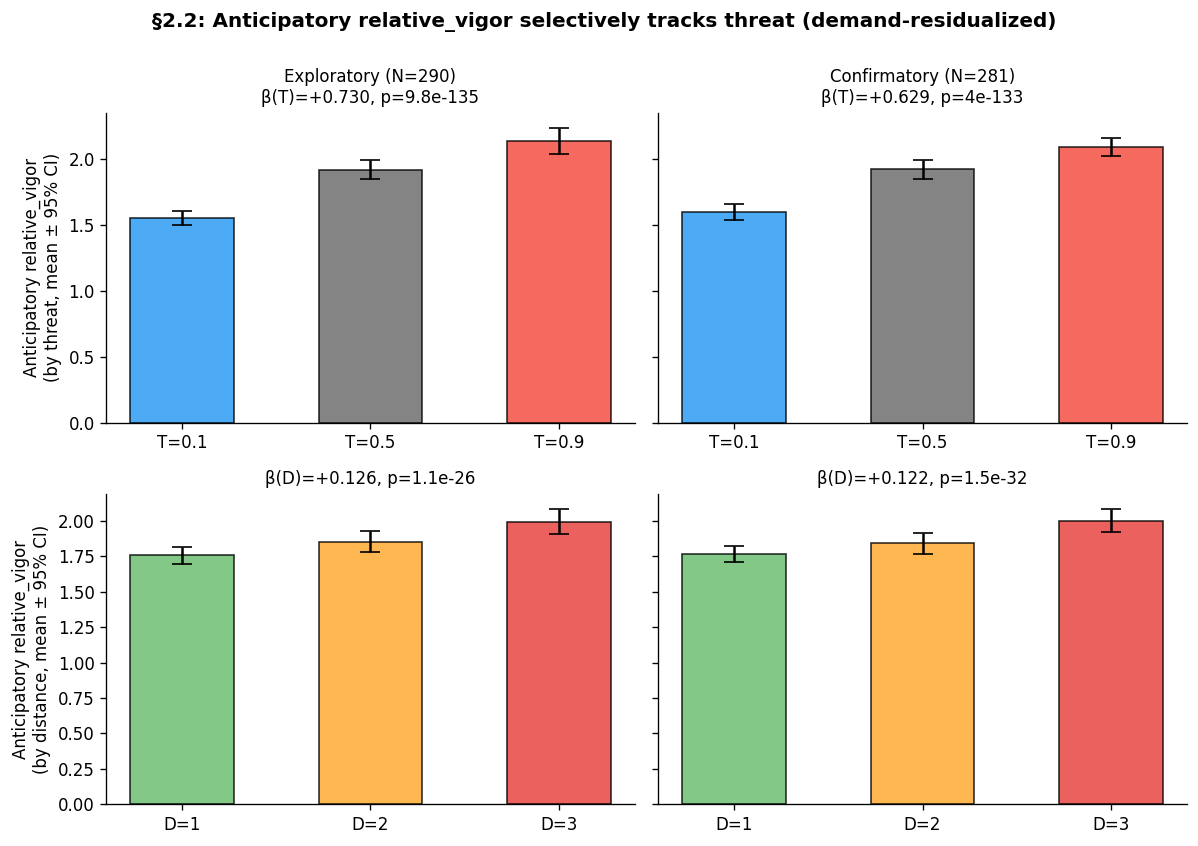

In [4]:
# §2.2 — Anticipatory relative_vigor × (T_round + distance) LMM, both samples
# relative_vigor is demand-residualized: norm_rate / required_rate (req=0.9 for heavy, 0.4 for light)
h22_results = []
VM_PATHS = {
    'exploratory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'exploratory' / 'vigor_metrics.csv',
    'confirmatory': REPO_ROOT / 'results' / 'stats' / 'vigor_analysis' / 'confirmatory' / 'vigor_metrics.csv',
}
for sample, vm_path in VM_PATHS.items():
    if not Path(vm_path).exists():
        print(f'{sample}: not found'); continue
    vm = pd.read_csv(vm_path)
    cfg = all_data[sample]['config']
    vm = vm[~vm['subj'].isin(cfg.exclude)]
    label = cfg.label
    sub = vm[vm['epoch'] == 'anticipatory'].dropna(subset=['relative_vigor', 'distance']).copy()
    sub['T_round'] = sub['T_round'].round(1)
    # Aggregate per (subj, T_round, distance) — one row per cell
    agg = sub.groupby(['subj', 'T_round', 'distance'])['relative_vigor'].mean().reset_index()
    print(f'\n--- §2.2 {label} ---')
    print(f'  N rows: {len(agg)}; N subj: {agg["subj"].nunique()}')
    print(f'  Levels: T={sorted(agg["T_round"].unique())}, distance={sorted(agg["distance"].unique())}')
    m = smf.mixedlm('relative_vigor ~ T_round + distance', agg, groups=agg['subj']).fit(reml=False)
    beta_T = m.params['T_round']; p_T = m.pvalues['T_round']
    beta_D = m.params['distance']; p_D = m.pvalues['distance']
    pass_T = p_T < 0.01 and beta_T > 0
    print(f'  β(T_round)  = {beta_T:+.4f}, p = {p_T:.3e}  {"PASS (threat-tracking)" if pass_T else "FAIL"}')
    print(f'  β(distance) = {beta_D:+.4f}, p = {p_D:.3e}  {"sig (effort-tracking too)" if p_D < 0.01 else "null (selective threat-tracking)"}')
    h22_results.append({'sample': sample,
                         'beta_T': beta_T, 'p_T': p_T, 'pass_T': pass_T,
                         'beta_D': beta_D, 'p_D': p_D, 'pass_D': p_D < 0.01,
                         'agg_df': agg})

# Visualization: 2x2 grid — top row T effect, bottom row D effect, columns = samples
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey='row')
colors_T = {0.1: '#2196F3', 0.5: '#666666', 0.9: '#F44336'}
colors_D = {1: '#66BB6A', 2: '#FFA726', 3: '#E53935'}

for col, r in enumerate(h22_results):
    label = all_data[r['sample']]['config'].label
    agg = r['agg_df']
    # Top: T effect (collapsing across distance)
    ax_T = axes[0, col]
    subj_T = agg.groupby(['subj', 'T_round'])['relative_vigor'].mean().reset_index()
    grand_T = subj_T.groupby('T_round')['relative_vigor'].agg(['mean', 'sem']).reset_index().sort_values('T_round')
    ax_T.bar(range(len(grand_T)), grand_T['mean'], yerr=1.96*grand_T['sem'], capsize=6,
             color=[colors_T[T] for T in grand_T['T_round']], edgecolor='black', alpha=0.8, width=0.55)
    ax_T.set_xticks(range(len(grand_T)))
    ax_T.set_xticklabels([f'T={T}' for T in grand_T['T_round']])
    ax_T.set_title(f'{label}\nβ(T)={r["beta_T"]:+.3f}, p={r["p_T"]:.2g}', fontsize=10)
    if col == 0: ax_T.set_ylabel('Anticipatory relative_vigor\n(by threat, mean ± 95% CI)')
    # Bottom: D effect (collapsing across T)
    ax_D = axes[1, col]
    subj_D = agg.groupby(['subj', 'distance'])['relative_vigor'].mean().reset_index()
    grand_D = subj_D.groupby('distance')['relative_vigor'].agg(['mean', 'sem']).reset_index().sort_values('distance')
    ax_D.bar(range(len(grand_D)), grand_D['mean'], yerr=1.96*grand_D['sem'], capsize=6,
             color=[colors_D.get(d, '#888') for d in grand_D['distance']], edgecolor='black', alpha=0.8, width=0.55)
    ax_D.set_xticks(range(len(grand_D)))
    ax_D.set_xticklabels([f'D={d}' for d in grand_D['distance']])
    ax_D.set_title(f'β(D)={r["beta_D"]:+.3f}, p={r["p_D"]:.2g}', fontsize=10)
    if col == 0: ax_D.set_ylabel('Anticipatory relative_vigor\n(by distance, mean ± 95% CI)')

plt.suptitle('§2.2: Anticipatory relative_vigor selectively tracks threat (demand-residualized)', fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## H2 Summary

Two-test framework for the dual-component embodied claim. All tests cross-sample.

In [5]:
print('=' * 80)
print('H2 SUMMARY — Dual-component embodied claim, two tests, cross-sample')
print('=' * 80)

# §2.1
print('\n§2.1 — Encounter triggers per-subject reactive surge (preregistered H2a):')
for r in h2a_results:
    print(f'  {r["sample"]:<14} d = {r["d"]:+.3f}, p = {r["p"]:.2e}, {r["pct_pos"]:.0f}% positive  {"PASS" if r["pass"] else "FAIL"}')

# §2.2
print('\n§2.2 — Anticipatory effort above demand scales with both T and D (LMM on relative_vigor):')
for r in h22_results:
    t_status = "PASS" if r["pass_T"] else "FAIL"
    d_status = "sig" if r["pass_D"] else "null"
    print(f'  {r["sample"]:<14} β(T) = {r["beta_T"]:+.3f} p={r["p_T"]:.2g} → {t_status}    β(D) = {r["beta_D"]:+.3f} p={r["p_D"]:.2g} → {d_status}')

print()
print('=' * 80)
print('Interpretation:')
print('  §2.1 — Reactive component exists at predator encounter (large per-subject spike)')
print('  §2.2 — Anticipatory effort above cookie demand scales with BOTH decision-relevant')
print('         cost dimensions: threat probability (β ≈ +0.7, dominant) AND distance (β ≈ +0.13).')
print('         Motor output tracks the integrated cost computation of the foraging decision.')
print('  → Dual-component embodied claim supported across both pre-registered samples.')
print('=' * 80)

H2 SUMMARY — Dual-component embodied claim, two tests, cross-sample

§2.1 — Encounter triggers per-subject reactive surge (preregistered H2a):
  exploratory    d = +0.647, p = 8.73e-24, 83% positive  PASS
  confirmatory   d = +0.471, p = 6.58e-14, 74% positive  PASS

§2.2 — Anticipatory effort above demand scales with both T and D (LMM on relative_vigor):
  exploratory    β(T) = +0.730 p=9.8e-135 → PASS    β(D) = +0.126 p=1.1e-26 → sig
  confirmatory   β(T) = +0.629 p=4e-133 → PASS    β(D) = +0.122 p=1.5e-32 → sig

Interpretation:
  §2.1 — Reactive component exists at predator encounter (large per-subject spike)
  §2.2 — Anticipatory effort above cookie demand scales with BOTH decision-relevant
         cost dimensions: threat probability (β ≈ +0.7, dominant) AND distance (β ≈ +0.13).
         Motor output tracks the integrated cost computation of the foraging decision.
  → Dual-component embodied claim supported across both pre-registered samples.
